In [ ]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Loading & Initial Pre-processing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Loading datasets
sales_no_outliers = pd.read_csv('/content/drive/MyDrive/PTTK/Cleaned_Online_Sales_No_Outliers.csv')
sales_vip = pd.read_csv('/content/drive/MyDrive/PTTK/Clean_Online_Sales_with_VIP_type.csv')
ecom_dataset = pd.read_csv('/content/drive/MyDrive/PTTK/cleaned_datasets/Cleaned_E_Commerce_Dataset.csv')
discount = pd.read_csv('/content/drive/MyDrive/PTTK/cleaned_datasets/Cleaned_Discount_Coupon.csv')
tax = pd.read_csv('/content/drive/MyDrive/PTTK/cleaned_datasets/Cleaned_Tax_amount.csv')

# Loading the specific cleaned sales files
sales_no_outliers['Transaction_Date'] = pd.to_datetime(sales_no_outliers['Transaction_Date'])
sales_no_outliers['Month'] = sales_no_outliers['Transaction_Date'].dt.strftime('%b')

print("--- Hệ thống đã sẵn sàng với dữ liệu sạch ---")

--- Hệ thống đã sẵn sàng với dữ liệu sạch ---


Inferential Statistics (D1)

/tmp/ipykernel_11630/651753819.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Coupon_Status', y='Line_Revenue', data=transaction_aov, showfliers=False, palette='pastel')
/tmp/ipykernel_11630/651753819.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Discount_pct', y='Line_Revenue', data=df_anova, showfliers=False, palette='viridis')


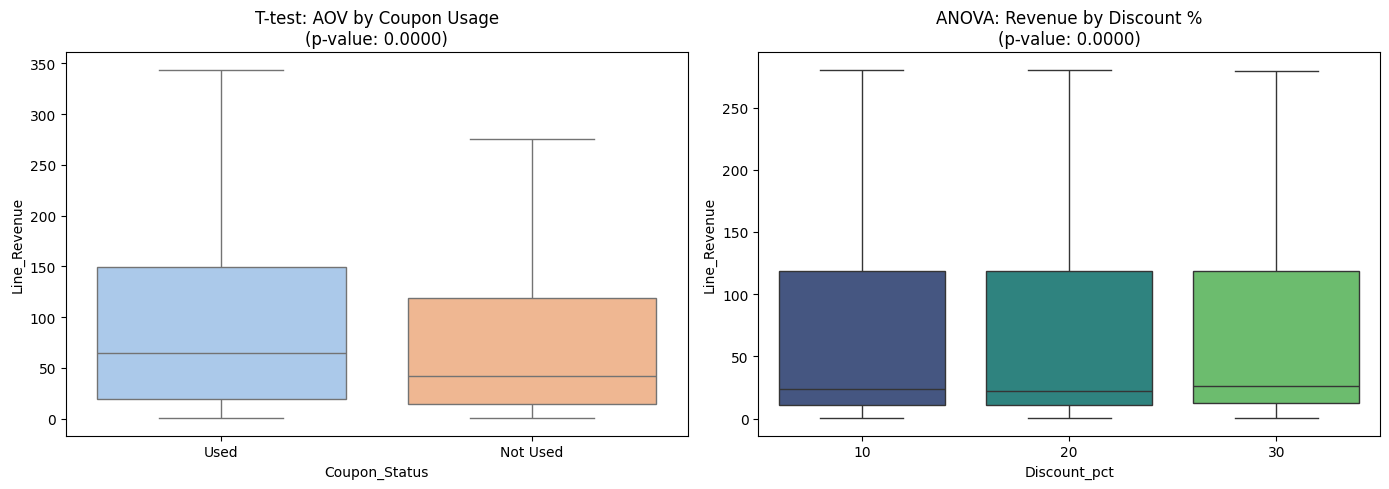

D1 - T-test p-value: 0.0000 | ANOVA p-value: 0.0000


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, f_oneway

# Loading and Preprocessing Data
df_sales = pd.read_csv('/content/drive/MyDrive/PTTK/Cleaned_Online_Sales_No_Outliers.csv')
df_coupon = pd.read_csv('/content/drive/MyDrive/PTTK/cleaned_datasets/Cleaned_Discount_Coupon.csv')

# Calculate revenue for each line
df_sales['Line_Revenue'] = df_sales['Quantity'] * df_sales['Avg_Price']
df_sales['Transaction_Date'] = pd.to_datetime(df_sales['Transaction_Date'])
df_sales['Month_Key'] = df_sales['Transaction_Date'].dt.strftime('%b')

# --- T-TEST (Compare AOV) ---
# Filter out 'Clicked', only include 'Used' and 'Not Used'
df_ttest = df_sales[df_sales['Coupon_Status'].isin(['Used', 'Not Used'])]
transaction_aov = df_ttest.groupby(['Transaction_ID', 'Coupon_Status'])['Line_Revenue'].sum().reset_index()

group_used = transaction_aov[transaction_aov['Coupon_Status'] == 'Used']['Line_Revenue']
group_not_used = transaction_aov[transaction_aov['Coupon_Status'] == 'Not Used']['Line_Revenue']
t_stat, t_p = ttest_ind(group_used, group_not_used, nan_policy='omit')

# --- PERFORM ANOVA (Compare revenue by percentage discount) ---
df_anova = pd.merge(df_sales, df_coupon[['Month', 'Product_Category', 'Discount_pct']],
                    left_on=['Month_Key', 'Product_Category'], right_on=['Month', 'Product_Category'], how='inner')


anova_groups = [group['Line_Revenue'] for name, group in df_anova.groupby('Discount_pct')]
f_stat, f_p = f_oneway(*anova_groups)

# DRAW ILLUSTRATIONS D1
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Coupon_Status', y='Line_Revenue', data=transaction_aov, showfliers=False, palette='pastel')
plt.title(f'T-test: AOV by Coupon Usage\n(p-value: {t_p:.4f})')

plt.subplot(1, 2, 2)
sns.boxplot(x='Discount_pct', y='Line_Revenue', data=df_anova, showfliers=False, palette='viridis')
plt.title(f'ANOVA: Revenue by Discount %\n(p-value: {f_p:.4f})')

plt.tight_layout()
plt.show()

print(f"D1 - T-test p-value: {t_p:.4f} | ANOVA p-value: {f_p:.4f}")

Correlation Analysis (D2)

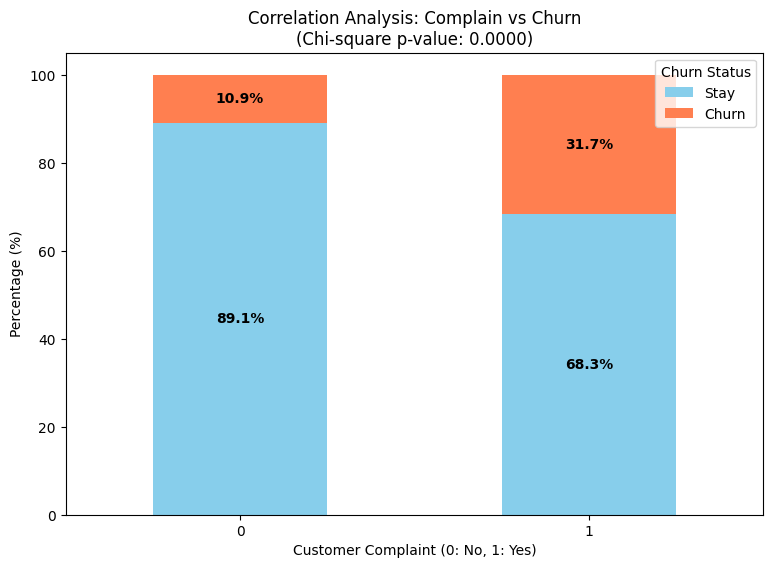

D2 - Chi-square p-value: 0.0000

Bảng tần suất thực tế:
Churn        0    1
Complain           
0         3586  440
1         1096  508


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Loading data
df_ecommerce = pd.read_csv('/content/drive/MyDrive/PTTK/cleaned_datasets/Cleaned_E_Commerce_Dataset.csv')

# --- IMPLEMENT CHI-SQUARE ---
# Create a cross table between Complain and Churn
contingency_table = pd.crosstab(df_ecommerce['Complain'], df_ecommerce['Churn'])
chi2, p_chi, dof, expected = chi2_contingency(contingency_table)

# --- DRAWING ILLUSTRATIONS D2 ---
# Convert to percentages for a more visual comparison
prop_table = pd.crosstab(df_ecommerce['Complain'], df_ecommerce['Churn'], normalize='index') * 100

ax = prop_table.plot(kind='bar', stacked=True, figsize=(9, 6), color=['#87CEEB', '#FF7F50'])
plt.title(f'Correlation Analysis: Complain vs Churn\n(Chi-square p-value: {p_chi:.4f})')
plt.xlabel('Customer Complaint (0: No, 1: Yes)')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn Status', labels=['Stay', 'Churn'], loc='upper right')

# Add percentage labels to each segment
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontweight='bold')

plt.xticks(rotation=0)
plt.show()

print(f"D2 - Chi-square p-value: {p_chi:.4f}")
print("\nBảng tần suất thực tế:")
print(contingency_table)